# LIME Field-Level Explainability — BERT + XGBoost (BayesSearchCV)\nExplains the actual best model using its real underlying fields (the ones fed into `serialize_row()` before BERT embedding), instead of uninterpretable `bert_pca_#` dimensions.\n\n**Pipeline explained:** raw fields → `serialize_row()` → clean → BERT (mean-pooled) → PCA(20) → spliced into full XGBoost feature vector → prediction.

## 1. Setup

In [1]:
import re, time, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, make_scorer

RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_COMPONENTS = 20
print("Device:", DEVICE)


Device: cuda


In [2]:
from lime.lime_tabular import LimeTabularExplainer


## 2. Load data

In [3]:
RAW_PATH = r"E:\NSU\cse445\EDA attempt3\Dataset\kickstarter_raw_before_encoding.csv"
TRAIN_PATH = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset\ML_train.csv"
TEST_PATH = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset\ML_test.csv"

raw_df   = pd.read_csv(RAW_PATH)
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Raw:", raw_df.shape, "| Train:", train_df.shape, "| Test:", test_df.shape)


Raw: (20000, 25) | Train: (16000, 81) | Test: (4000, 81)


## 3. Serialization template (identical to training pipeline)

In [4]:
def serialize_row(row):
    """EXACT copy of the row-to-text template from kickstarter_nlp_embeddings_creation.ipynb"""
    text = (
        f"This Kickstarter project is in the {row['category_parent']} category, "
        f"specifically {row['category_name']}. "
        f"It was launched from {row['location_country']}"
        + (f", {row['location_state']}" if pd.notna(row.get('location_state')) else "")
        + f", with a location type of {row['location_type']}. "
        f"The campaign country is {row['country']} and currency used is {row['currency']}. "
        f"The funding goal was {row['goal_usd']:.2f} USD. "
        f"The campaign ran for {row['duration_days']:.1f} days "
        f"with a prelaunch period of {row['prelaunch_days']:.1f} days. "
        f"The project title had {int(row['name_word_count'])} words "
        f"and the blurb had {int(row['blurb_word_count'])} words. "
        f"It was launched in {int(row['launch_month'])}/{int(row['launch_year'])} "
        f"at hour {int(row['launch_hour'])} on weekday {int(row['launch_weekday'])}. "
        f"{'A video was included.' if row['has_video'] == 1 else 'No video was included.'} "
        f"{'Prelaunch marketing was activated.' if row['prelaunch_activated'] == 1 else 'No prelaunch marketing was activated.'}"
    )
    return text

def basic_clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

SERIALIZE_FIELDS = [
    "category_parent", "category_name", "location_country", "location_state",
    "location_type", "country", "currency", "goal_usd",
    "duration_days", "prelaunch_days", "name_word_count", "blurb_word_count",
    "launch_month", "launch_year", "launch_hour", "launch_weekday",
    "has_video", "prelaunch_activated"
]
NUMERIC_FIELDS = [
    "goal_usd","duration_days","prelaunch_days",
    "name_word_count","blurb_word_count","launch_month","launch_year",
    "launch_hour","launch_weekday","has_video","prelaunch_activated"
]
CATEGORICAL_FIELDS = [f for f in SERIALIZE_FIELDS if f not in NUMERIC_FIELDS]


## 4. BERT embedder

In [5]:
BERT_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert_model = AutoModel.from_pretrained(BERT_NAME).to(DEVICE).eval()

@torch.no_grad()
def embed_texts(texts, batch_size=32):
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        out = bert_model(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        summed = (out * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        mean_pooled = (summed / counts).cpu().numpy()
        all_vecs.append(mean_pooled)
    return np.vstack(all_vecs)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 5. Rebuild BERT → PCA pipeline (fit PCA on train only, exactly as in training)

In [6]:
raw_df["serialized_text"] = raw_df.apply(serialize_row, axis=1)
raw_df["clean_text"] = raw_df["serialized_text"].apply(basic_clean)

bert_all = embed_texts(raw_df["clean_text"].tolist())
bert_cols = [f"bert_{i}" for i in range(bert_all.shape[1])]
bert_df = pd.DataFrame(bert_all, columns=bert_cols)
bert_df.insert(0, "id", raw_df["id"].values)

train_ids = set(train_df["id"])
train_mask = bert_df["id"].isin(train_ids)

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_df.loc[train_mask, bert_cols])
reduced_all = pca.transform(bert_df[bert_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_df["id"].values)

print("Explained variance:", pca.explained_variance_ratio_.sum())


Explained variance: 0.7395077


## 6. Build X/y (mirrors `bert_xgb_bayes.ipynb`)

In [7]:
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test  = test_df.merge(reduced_df, on="id", how="left")

X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
X_test  = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
y_train = merged_train[TARGET_LOG].copy()
y_test  = merged_test[TARGET_LOG].copy()

FEATURE_COLS = list(X_train.columns)
assert list(X_train.columns) == list(X_test.columns)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (16000, 97) | X_test: (4000, 97)


## 7. Retrain BERT + XGBoost (BayesSearchCV) — the actual best model

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)
CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_bayes_space = {
    "n_estimators":     Integer(200, 500),
    "learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
    "max_depth":        Integer(4, 9),
    "min_child_weight": Integer(1, 7),
    "subsample":        Real(0.7, 1.0),
    "colsample_bytree": Real(0.7, 1.0),
    "reg_alpha":        Real(1e-3, 0.5, prior="log-uniform"),
    "reg_lambda":       Real(0.5, 3.0),
}

base_estimator = XGBRegressor(
    objective="reg:squarederror", eval_metric="rmse",
    tree_method="hist", device="cuda" if DEVICE == "cuda" else "cpu",
    random_state=RANDOM_STATE,
)

search = BayesSearchCV(
    estimator=base_estimator, search_spaces=xgb_bayes_space, n_iter=4,
    scoring=rmse_scorer, cv=CV, n_jobs=1, random_state=RANDOM_STATE, verbose=0, refit=True,
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Test RMSE_log:", rmse(y_test, best_model.predict(X_test)))


Test RMSE_log: 2.2698321705681943


## 8. Align raw serialize_row fields to test rows + background sample

In [9]:
test_ids = merged_test["id"].values
raw_indexed = raw_df.set_index("id")
raw_fields_test = raw_indexed.loc[test_ids, SERIALIZE_FIELDS].reset_index(drop=True)

BG_SIZE = 100
bg_fields = raw_fields_test.sample(BG_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
print("Test rows:", raw_fields_test.shape, "| Background rows:", bg_fields.shape)


Test rows: (4000, 18) | Background rows: (100, 18)


## 9. End-to-end wrapper: raw fields → serialize → BERT → PCA → full feature vector → predict

In [10]:
def fields_to_full_X(fields_df, base_row):
    """raw fields -> serialize_row -> BERT -> PCA -> spliced into full XGBoost feature vector"""
    texts = fields_df.apply(serialize_row, axis=1).apply(basic_clean).tolist()
    bert_vecs = embed_texts(texts)
    pca_vecs = pca.transform(bert_vecs)

    N = len(fields_df)
    X_out = pd.DataFrame(np.tile(base_row[FEATURE_COLS].values, (N, 1)), columns=FEATURE_COLS)
    for i, c in enumerate(reduced_cols):
        X_out[c] = pca_vecs[:, i]
    return X_out.values

def make_predict_fn(base_row, decode_categoricals=False):
    """decode_categoricals=True: predict_fn receives an all-numeric matrix
    (LIME's internal format) and must decode categorical codes back to strings
    before calling serialize_row(). decode_categoricals=False: predict_fn
    receives raw fields directly (used by SHAP, which keeps strings as-is)."""
    def predict_fn(field_matrix):
        if decode_categoricals:
            fields_df = decode_fields(field_matrix)
        else:
            fields_df = pd.DataFrame(field_matrix, columns=SERIALIZE_FIELDS)
            for c in NUMERIC_FIELDS:
                fields_df[c] = pd.to_numeric(fields_df[c])
        X_full = fields_to_full_X(fields_df, base_row)
        return best_model.predict(X_full)
    return predict_fn


In [21]:
lime_explanations = {}
lime_results = []

for idx in showcase_idx:
    base_row = merged_test.iloc[idx]
    predict_fn = make_predict_fn(base_row, decode_categoricals=True)
    instance_encoded = encode_fields(raw_fields_test.iloc[[idx]])[0]

    exp = lime_explainer.explain_instance(
        instance_encoded, predict_fn, num_features=len(SERIALIZE_FIELDS)
    )
    lime_explanations[idx] = exp
    lime_results.append({"row_index": int(idx), **dict(exp.as_list())})
    exp.save_to_file(f"lime_explanation_row_{idx}.html")
    print(f"Row {idx} explained")

assert len(lime_explanations) > 0, "lime_explanations is empty — check the loop above for errors"

with open("lime_field_explanations.json", "w") as f:
    json.dump(lime_results, f, indent=2, default=str)
print("Saved lime_field_explanations.json + per-row HTML files")

Row 3405 explained
Row 3925 explained
Row 3921 explained
Row 1097 explained
Row 2072 explained
Row 1289 explained
Row 555 explained
Row 3491 explained
Row 527 explained
Saved lime_field_explanations.json + per-row HTML files


## 10. Pick rows to explain

In [11]:
N_EXPLAIN = 20
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(raw_fields_test), N_EXPLAIN, replace=False)
print("Explaining", N_EXPLAIN, "test rows, indices:", sample_idx[:10], "...")


Explaining 20 test rows, indices: [ 555 3491  527 3925 2989   70 1756  211  196  803] ...


## 11. LIME explainer setup (field-level, categorical fields marked)

In [12]:
from sklearn.preprocessing import LabelEncoder

cat_idx = [SERIALIZE_FIELDS.index(c) for c in CATEGORICAL_FIELDS]

# LIME requires an all-numeric matrix. Fit a LabelEncoder per categorical field
# (on background + test rows combined, so all categories seen are covered).
label_encoders = {}
encoding_pool = pd.concat([bg_fields, raw_fields_test], ignore_index=True)

for f in CATEGORICAL_FIELDS:
    le = LabelEncoder()
    le.fit(encoding_pool[f].astype(str))
    label_encoders[f] = le

def encode_fields(fields_df):
    """raw fields (strings + numbers) -> all-numeric matrix for LIME"""
    out = fields_df.copy()
    for f in CATEGORICAL_FIELDS:
        out[f] = label_encoders[f].transform(out[f].astype(str))
    for f in NUMERIC_FIELDS:
        out[f] = pd.to_numeric(out[f])
    return out[SERIALIZE_FIELDS].values.astype(float)

def decode_fields(numeric_matrix):
    """LIME's numeric matrix -> raw fields (strings + numbers) for serialize_row()"""
    df = pd.DataFrame(numeric_matrix, columns=SERIALIZE_FIELDS)
    for f in CATEGORICAL_FIELDS:
        codes = df[f].round().astype(int).clip(0, len(label_encoders[f].classes_) - 1)
        df[f] = label_encoders[f].inverse_transform(codes)
    for f in NUMERIC_FIELDS:
        df[f] = pd.to_numeric(df[f])
    return df

categorical_names = {
    idx: list(label_encoders[SERIALIZE_FIELDS[idx]].classes_)
    for idx in cat_idx
}

bg_fields_encoded = encode_fields(bg_fields)

lime_explainer = LimeTabularExplainer(
    training_data=bg_fields_encoded,
    feature_names=SERIALIZE_FIELDS,
    categorical_features=cat_idx,
    categorical_names=categorical_names,
    mode="regression",
    random_state=RANDOM_STATE
)


## 12. Compute LIME explanations

In [13]:
N_LIME = 5  # LIME per-instance is slow; explain a handful of representative rows
lime_explanations = {}
lime_results = []

for idx in sample_idx[:N_LIME]:
    base_row = merged_test.iloc[idx]
    predict_fn = make_predict_fn(base_row, decode_categoricals=True)
    instance_encoded = encode_fields(raw_fields_test.iloc[[idx]])[0]

    exp = lime_explainer.explain_instance(
        instance_encoded, predict_fn, num_features=len(SERIALIZE_FIELDS)
    )
    lime_explanations[idx] = exp
    lime_results.append({"row_index": int(idx), **dict(exp.as_list())})
    exp.save_to_file(f"lime_explanation_row_{idx}.html")
    print(f"Row {idx} explained")

assert len(lime_explanations) > 0, "lime_explanations is empty — check the loop above for errors"

with open("lime_field_explanations.json", "w") as f:
    json.dump(lime_results, f, indent=2, default=str)
print("Saved lime_field_explanations.json + per-row HTML files")


Row 555 explained
Row 3491 explained
Row 527 explained
Row 3925 explained
Row 2989 explained
Saved lime_field_explanations.json + per-row HTML files


## 13. Numeric output — LIME weights matrix (instances × fields, CSV)

In [14]:
# Numeric SHAP-equivalent output for LIME: one row per explained instance,
# one column per raw field (SERIALIZE_FIELDS), values = LIME weight for that field.
# LIME's as_list() returns condition strings (e.g. "goal_usd <= 100.00"), so we
# map each condition back to its underlying field name.
def condition_to_field(condition_str):
    for f in SERIALIZE_FIELDS:
        if f in condition_str:
            return f
    return condition_str  # fallback, shouldn't happen

lime_matrix_rows = []
for idx, exp in lime_explanations.items():
    row_weights = {f: 0.0 for f in SERIALIZE_FIELDS}
    for condition_str, weight in exp.as_list():
        field = condition_to_field(condition_str)
        row_weights[field] = weight
    lime_matrix_rows.append(row_weights)

lime_matrix_df = pd.DataFrame(lime_matrix_rows, index=[f"row_{i}" for i in lime_explanations.keys()])
lime_matrix_df = lime_matrix_df[SERIALIZE_FIELDS]  # consistent column order
lime_matrix_df.to_csv("lime_field_weights_matrix.csv")
print("Saved lime_field_weights_matrix.csv")
lime_matrix_df


Saved lime_field_weights_matrix.csv


,category_parent,category_name,location_country,location_state,location_type,country,currency,goal_usd,duration_days,prelaunch_days,name_word_count,blurb_word_count,launch_month,launch_year,launch_hour,launch_weekday,has_video,prelaunch_activated
row_555,-0.185437,-0.037487,0.037779,-0.074918,-0.007423,0.073896,0.067052,-0.027545,0.034765,-0.017512,0.000388,0.021200,0.003872,-0.077644,-0.006891,-0.051379,0.007832,-0.021257
row_3491,0.030484,0.027783,0.524677,0.515023,0.069391,0.535602,0.401285,0.014891,0.001637,-0.015159,-0.012405,0.022377,-0.007423,-0.003477,-0.018756,-0.008083,-0.005492,-0.016427
row_527,-0.060239,-0.005966,0.066321,0.084488,0.021631,-0.018761,0.008393,0.006535,0.016950,0.005386,-0.009553,-0.020585,-0.005804,-0.032283,0.022734,-0.002036,-0.015797,0.030167
row_3925,0.273982,0.082518,0.080383,0.074108,0.055477,0.072661,0.082206,-0.064771,-0.000881,0.041346,-0.019713,-0.022915,-0.001230,0.055848,0.006573,0.094731,-0.013257,0.009960
row_2989,0.228687,-0.078128,0.138930,-0.065502,0.067139,0.171281,0.245060,-0.026132,0.030560,0.006565,-0.015510,0.009440,-0.008461,0.150225,0.016379,-0.004969,0.010461,0.019922


## 14. Numeric output — mean |weight| per field (CSV)

In [15]:
# Numeric summary: mean |LIME weight| per field across all explained instances
# (the numeric table backing the aggregated importance chart below)
lime_mean_abs_weight = lime_matrix_df.abs().mean().sort_values(ascending=False)
lime_mean_abs_weight.to_csv("lime_field_mean_abs_weight.csv", header=["mean_abs_lime_weight"])
print("Saved lime_field_mean_abs_weight.csv")
lime_mean_abs_weight


Saved lime_field_mean_abs_weight.csv


country                0.174440
location_country       0.169618
location_state         0.162808
currency               0.160799
category_parent        0.155766
launch_year            0.063895
category_name          0.046376
location_type          0.044212
launch_weekday         0.032240
goal_usd               0.027975
prelaunch_activated    0.019546
blurb_word_count       0.019303
prelaunch_days         0.017194
duration_days          0.016958
launch_hour            0.014267
name_word_count        0.011514
has_video              0.010568
launch_month           0.005358
dtype: float64

## 15. Graph set 1 — Per-instance LIME bar charts (native local explanation)

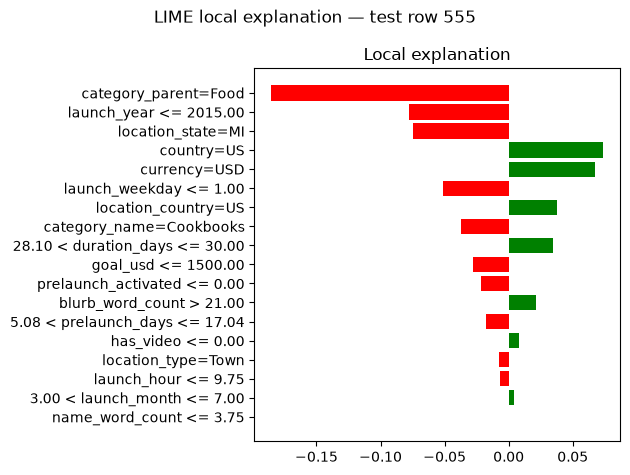

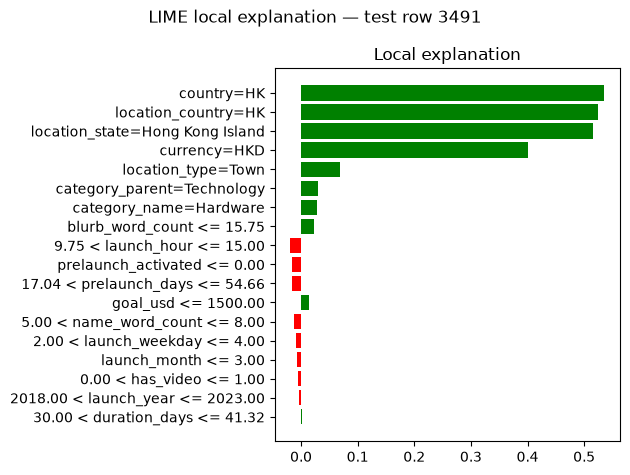

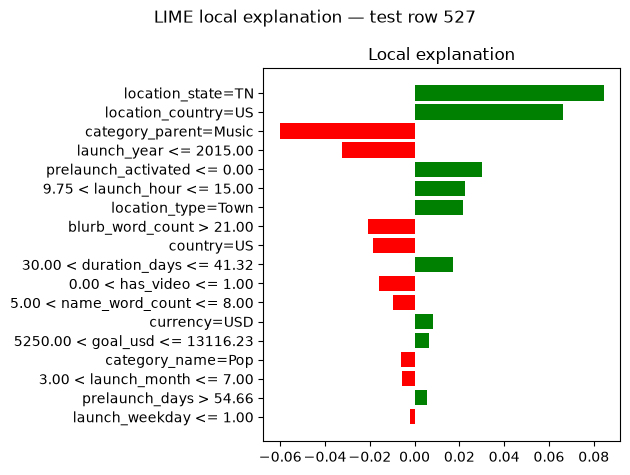

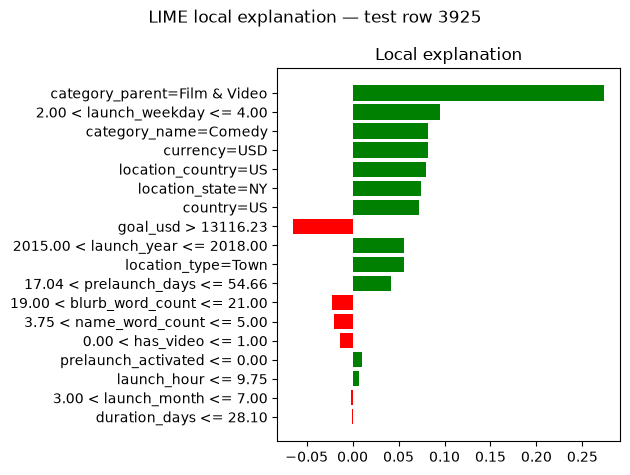

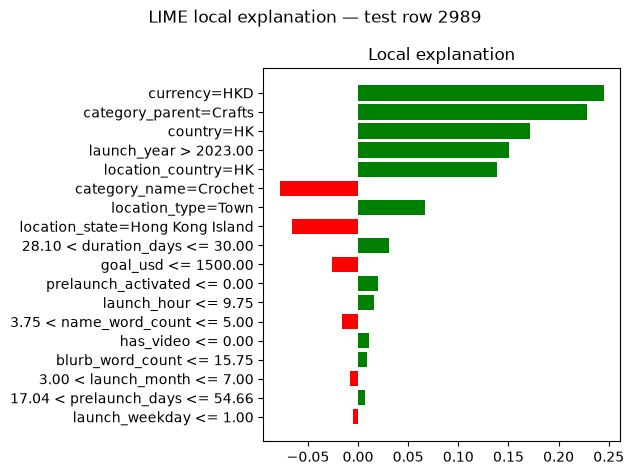

In [16]:
# Graph set 1: one bar chart per explained instance (LIME's native local feature-weight plot)
for idx, exp in lime_explanations.items():
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME local explanation — test row {idx}")
    fig.tight_layout()
    fig.savefig(f"lime_bar_row_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 16. Graph 2 — Aggregated mean |weight| per field across instances

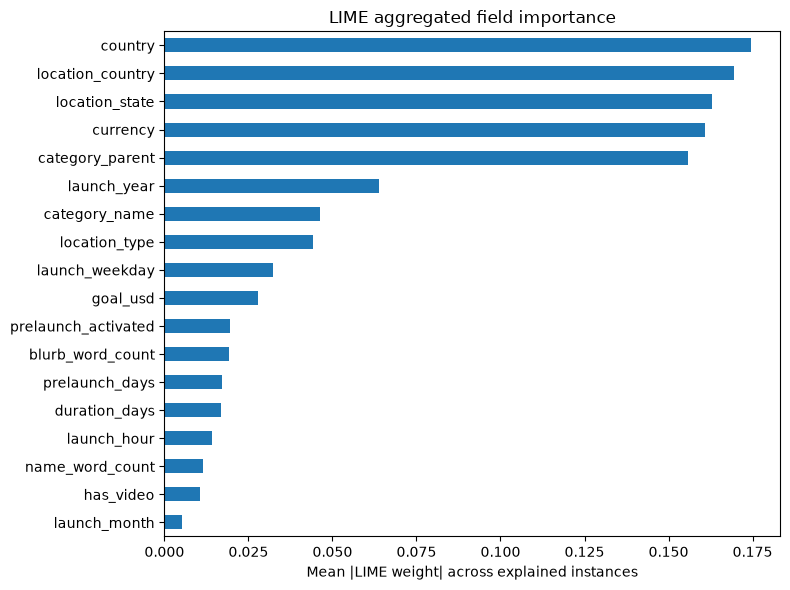

In [17]:
# Graph 2: aggregated view — average |weight| per field across all explained LIME instances
plt.figure(figsize=(8, 6))
lime_mean_abs_weight.sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Mean |LIME weight| across explained instances")
plt.title("LIME aggregated field importance")
plt.tight_layout()
plt.savefig("lime_aggregated_field_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 17. Graph 3 — Heatmap of LIME weights (instances × fields)

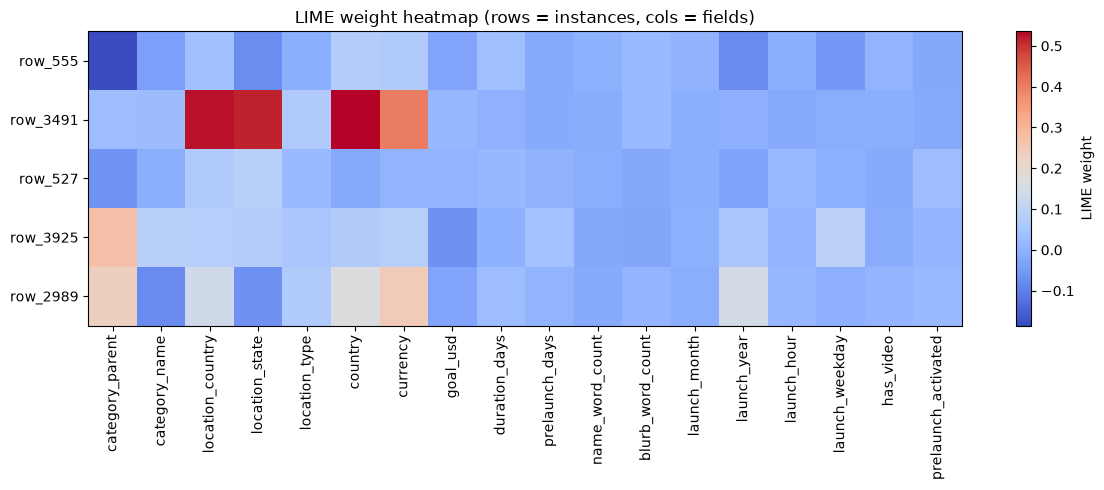

In [18]:
# Graph 3: heatmap of LIME weights across instances x fields (raw, signed)
plt.figure(figsize=(12, 5))
plt.imshow(lime_matrix_df.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="LIME weight")
plt.xticks(range(len(lime_matrix_df.columns)), lime_matrix_df.columns, rotation=90)
plt.yticks(range(len(lime_matrix_df.index)), lime_matrix_df.index)
plt.title("LIME weight heatmap (rows = instances, cols = fields)")
plt.tight_layout()
plt.savefig("lime_heatmap_instances_fields.png", dpi=150, bbox_inches="tight")
plt.show()


## Outputs\n- `lime_field_explanations.json` (raw per-instance condition/weight pairs)\n- `lime_field_weights_matrix.csv` (numeric matrix: instances × fields)\n- `lime_field_mean_abs_weight.csv` (numeric: mean |weight| per field)\n- `lime_explanation_row_<idx>.html` (per explained row)\n- `lime_bar_row_<idx>.png` (per explained row)\n- `lime_aggregated_field_importance.png`\n- `lime_heatmap_instances_fields.png`

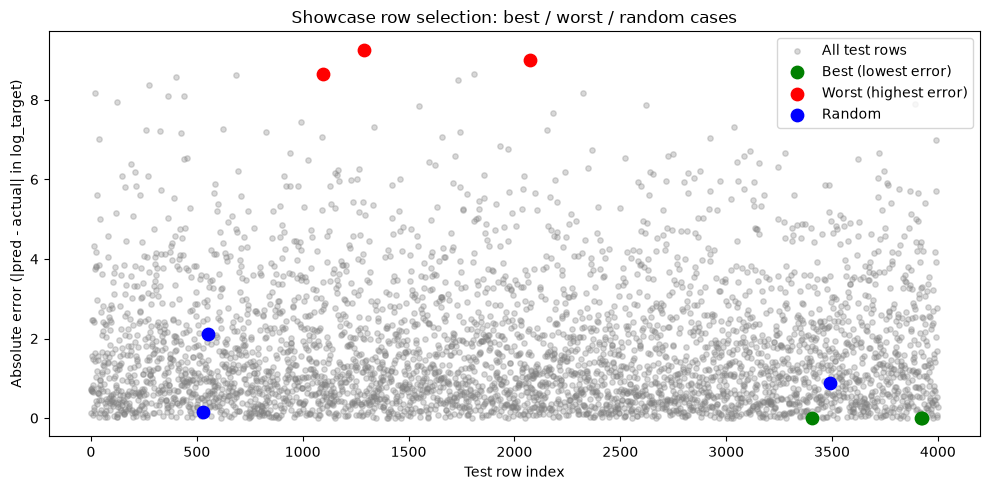

In [20]:
plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_test)), test_errors, alpha=0.3, s=15, color="gray", label="All test rows")
plt.scatter(best_idx, test_errors[best_idx], color="green", s=80, label="Best (lowest error)")
plt.scatter(worst_idx, test_errors[worst_idx], color="red", s=80, label="Worst (highest error)")
plt.scatter(random_idx, test_errors[random_idx], color="blue", s=80, label="Random")
plt.xlabel("Test row index")
plt.ylabel("Absolute error (|pred - actual| in log_target)")
plt.title("Showcase row selection: best / worst / random cases")
plt.legend()
plt.tight_layout()
plt.savefig("showcase_case_selection.png", dpi=150, bbox_inches="tight")
plt.show()